# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan — Jaya Jaya Institut

- **Nama:** Emilia Loho
- **Email:** lohoemilia@gmail.com
- **ID Dicoding:** emilia_loho


## 1. Business Understanding

Jaya Jaya Institut adalah institusi pendidikan tinggi yang berdiri sejak tahun 2000 dan telah mencetak banyak lulusan bereputasi baik. Namun, terdapat banyak siswa yang tidak menyelesaikan pendidikannya alias **dropout**. Tingkat dropout yang tinggi merugikan institusi secara finansial maupun reputasi.

### Permasalahan Bisnis
1. Tingkat dropout siswa yang tinggi, sementara faktor-faktor utama penyebabnya belum diketahui secara pasti.
2. Institusi belum memiliki cara untuk **mendeteksi sedini mungkin** siswa yang berisiko dropout agar dapat diberikan bimbingan khusus.
3. Institusi membutuhkan **dashboard monitoring** untuk memahami data dan memantau performa siswa.

### Cakupan Proyek
1. Melakukan analisis data (EDA) untuk menemukan faktor-faktor yang memengaruhi dropout.
2. Membangun model machine learning untuk memprediksi risiko dropout siswa.
3. Membuat business dashboard (Metabase) untuk monitoring performa siswa.
4. Membangun prototype prediksi berbasis Streamlit yang di-deploy ke Streamlit Community Cloud.
5. Memberikan rekomendasi action items untuk menurunkan tingkat dropout.


## 2. Persiapan

**Sumber data:** [Dicoding — students' performance dataset](https://github.com/dicodingacademy/dicoding_dataset/blob/main/students_performance/README.md) (4.424 baris × 37 kolom).

Setup environment (proyek ini menggunakan **Python 3.11**):
```bash
python --version                 # pastikan Python 3.11+
pip install -r requirements.txt
```


In [1]:
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay,
                             accuracy_score, classification_report, f1_score,
                             precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

# Palet konsisten: merah-oranye = Dropout (perhatian), biru netral = lainnya
PAL = {"Dropout": "#D64541", "Graduate": "#4C72B0", "Enrolled": "#9AA5B1"}
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [2]:
df = pd.read_csv(
    "https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/main/students_performance/data.csv",
    sep=";",
)
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 3. Data Understanding

Dataset berisi 37 kolom yang mencakup data demografi (usia, gender, status pernikahan), sosial-ekonomi (beasiswa, status pembayaran, pekerjaan orang tua), dan performa akademik (nilai masuk, jumlah SKS yang diambil/lulus per semester, nilai per semester). Kolom target adalah **Status**: `Dropout`, `Enrolled`, atau `Graduate`.

In [3]:
print("Shape:", df.shape)
print("Missing values:", df.isna().sum().sum())
print("Duplicated rows:", df.duplicated().sum())
df.describe().T.head(15)

Shape: (4424, 37)
Missing values: 0
Duplicated rows: 0


,count,mean,std,min,25%,50%,75%,max
Marital_status,4424.0,1.178571,0.605747,1.0,1.0,1.0,1.0,6.0
Application_mode,4424.0,18.669078,17.484682,1.0,1.0,17.0,39.0,57.0
Application_order,4424.0,1.727848,1.313793,0.0,1.0,1.0,2.0,9.0
Course,4424.0,8856.642631,2063.566416,33.0,9085.0,9238.0,9556.0,9991.0
Daytime_evening_attendance,4424.0,0.890823,0.311897,0.0,1.0,1.0,1.0,1.0
Previous_qualification,4424.0,4.577758,10.216592,1.0,1.0,1.0,1.0,43.0
Previous_qualification_grade,4424.0,132.613314,13.188332,95.0,125.0,133.1,140.0,190.0
Nacionality,4424.0,1.873192,6.914514,1.0,1.0,1.0,1.0,109.0
Mothers_qualification,4424.0,19.561935,15.603186,1.0,2.0,19.0,37.0,44.0
Fathers_qualification,4424.0,22.275316,15.343108,1.0,3.0,19.0,37.0,44.0


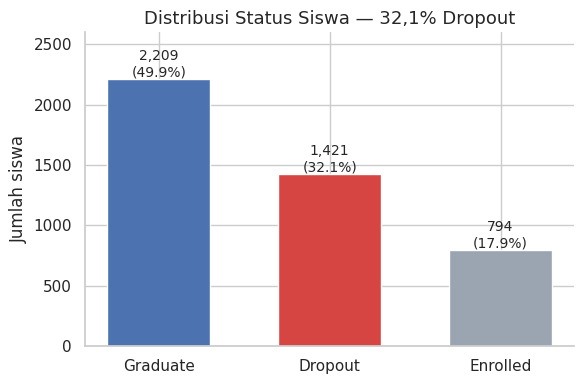

In [4]:
# Distribusi status siswa
counts = df["Status"].value_counts()
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index, counts.values,
              color=[PAL[s] for s in counts.index], width=0.6)
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 25,
            f"{v:,}\n({v / len(df):.1%})", ha="center", fontsize=10)
ax.set_title("Distribusi Status Siswa — 32,1% Dropout", fontsize=13)
ax.set_ylabel("Jumlah siswa")
ax.set_ylim(0, 2600)
plt.tight_layout()
plt.show()

**Insight:** dari 4.424 siswa, **1.421 (32,1%) dropout** — hampir 1 dari 3 siswa. Ini mengonfirmasi bahwa dropout adalah masalah serius bagi Jaya Jaya Institut.

## 4. Exploratory Data Analysis (EDA)

### 4.1 Faktor finansial

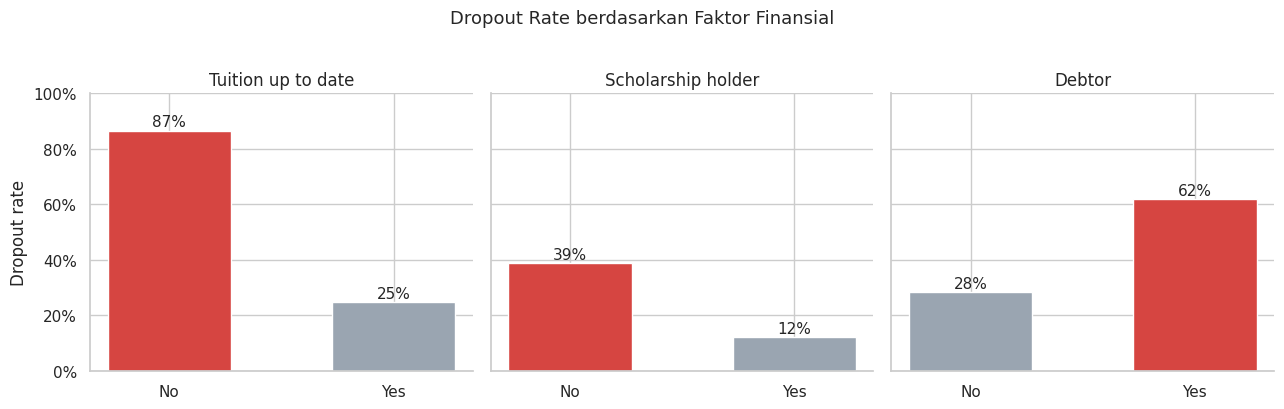

In [5]:
fin_map = {"Tuition_fees_up_to_date": "Tuition up to date",
           "Scholarship_holder": "Scholarship holder",
           "Debtor": "Debtor"}
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, (col, label) in zip(axes, fin_map.items()):
    rate = df.groupby(col)["Status"].apply(lambda s: (s == "Dropout").mean())
    rate.index = rate.index.map({0: "No", 1: "Yes"})
    bars = ax.bar(rate.index, rate.values, color=["#9AA5B1", "#D64541"]
                  if rate.values[1] > rate.values[0] else ["#D64541", "#9AA5B1"],
                  width=0.55)
    for b, v in zip(bars, rate.values):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.015, f"{v:.0%}",
                ha="center", fontsize=11)
    ax.set_title(label)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
axes[0].set_ylabel("Dropout rate")
fig.suptitle("Dropout Rate berdasarkan Faktor Finansial", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Insight:**
- Siswa yang **menunggak biaya kuliah** memiliki dropout rate **86,6%** vs 24,7% yang lancar — faktor tunggal paling mencolok.
- Siswa **penerima beasiswa** jauh lebih jarang dropout (12,2% vs 38,7%).
- Siswa berstatus **debtor** dropout 62,0% vs 28,3%.

Faktor finansial adalah sinyal risiko yang sangat kuat dan dapat dipantau institusi secara real-time.

### 4.2 Performa akademik semester awal

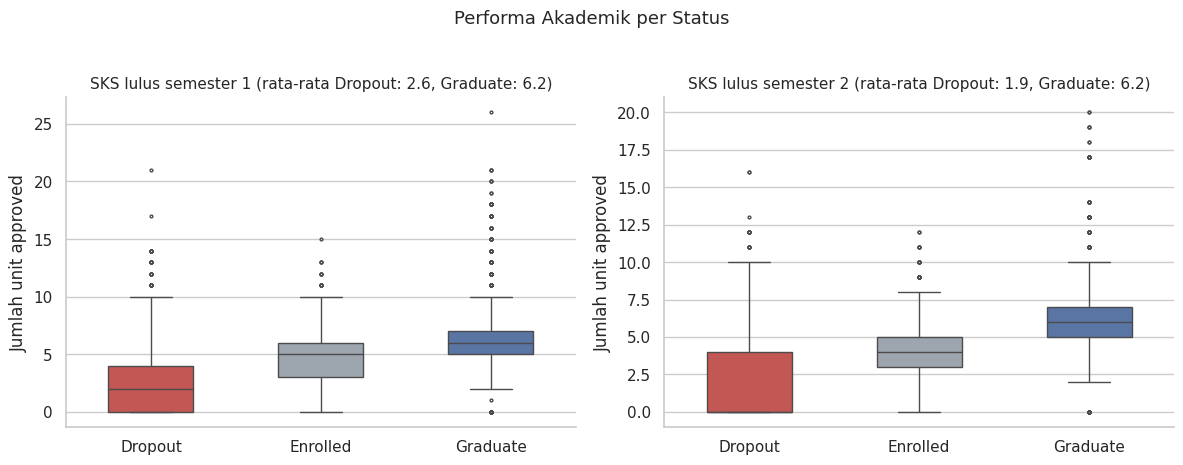

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
order = ["Dropout", "Enrolled", "Graduate"]
for ax, col, title in zip(
        axes,
        ["Curricular_units_1st_sem_approved", "Curricular_units_2nd_sem_approved"],
        ["SKS lulus semester 1", "SKS lulus semester 2"]):
    sns.boxplot(data=df, x="Status", y=col, order=order, hue="Status",
                palette=PAL, legend=False, ax=ax, width=0.5, fliersize=2)
    means = df.groupby("Status")[col].mean()
    ax.set_title(f"{title} (rata-rata Dropout: {means['Dropout']:.1f}, "
                 f"Graduate: {means['Graduate']:.1f})", fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("Jumlah unit approved")
fig.suptitle("Performa Akademik per Status", fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

**Insight:** siswa dropout rata-rata hanya lulus **±1,9 unit** di semester 2, sedangkan siswa graduate lulus ±6,2 unit. Jumlah unit yang lulus di semester 1–2 adalah **prediktor terkuat** dropout — artinya risiko sudah terdeteksi sejak tahun pertama.

### 4.3 Faktor demografi

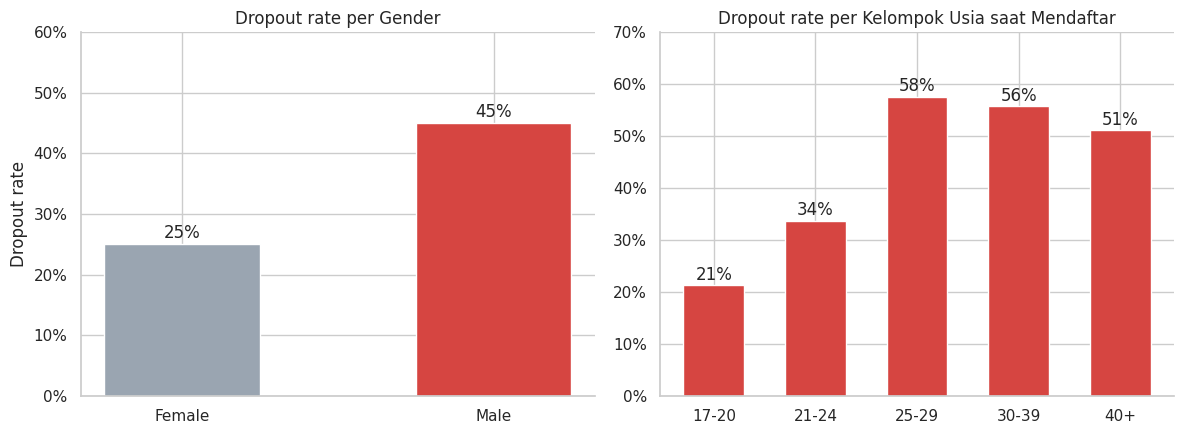

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Gender
rate_g = df.groupby("Gender")["Status"].apply(lambda s: (s == "Dropout").mean())
rate_g.index = rate_g.index.map({0: "Female", 1: "Male"})
bars = axes[0].bar(rate_g.index, rate_g.values, color=["#9AA5B1", "#D64541"], width=0.5)
for b, v in zip(bars, rate_g.values):
    axes[0].text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.0%}", ha="center")
axes[0].set_title("Dropout rate per Gender")
axes[0].set_ylim(0, 0.6)
axes[0].yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
axes[0].set_ylabel("Dropout rate")

# Umur saat mendaftar
age_grp = pd.cut(df["Age_at_enrollment"], [16, 20, 24, 29, 39, 70],
                 labels=["17-20", "21-24", "25-29", "30-39", "40+"])
rate_a = df.groupby(age_grp, observed=True)["Status"].apply(lambda s: (s == "Dropout").mean())
bars = axes[1].bar(rate_a.index.astype(str), rate_a.values, color="#D64541", width=0.6)
for b, v in zip(bars, rate_a.values):
    axes[1].text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.0%}", ha="center")
axes[1].set_title("Dropout rate per Kelompok Usia saat Mendaftar")
axes[1].set_ylim(0, 0.7)
axes[1].yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")

plt.tight_layout()
plt.show()

**Insight:** siswa laki-laki dropout hampir 2× lebih sering (45,1% vs 25,1%), dan siswa yang mendaftar di usia **25+ tahun** memiliki dropout rate >51% — kemungkinan karena bekerja sambil kuliah.

### 4.4 Dropout per program studi (course)

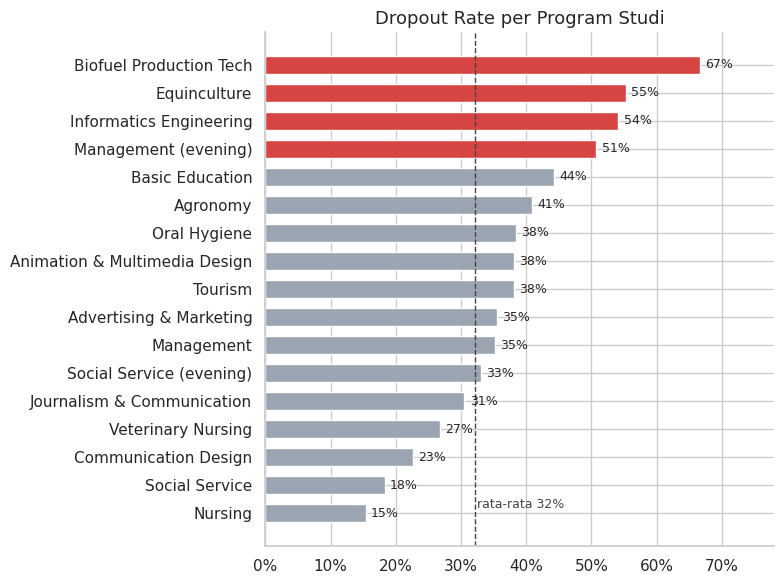

In [8]:
COURSE = {33: "Biofuel Production Tech", 171: "Animation & Multimedia Design",
          8014: "Social Service (evening)", 9003: "Agronomy",
          9070: "Communication Design", 9085: "Veterinary Nursing",
          9119: "Informatics Engineering", 9130: "Equinculture",
          9147: "Management", 9238: "Social Service", 9254: "Tourism",
          9500: "Nursing", 9556: "Oral Hygiene", 9670: "Advertising & Marketing",
          9773: "Journalism & Communication", 9853: "Basic Education",
          9991: "Management (evening)"}
course_rate = (df.assign(course=df["Course"].map(COURSE))
                 .groupby("course")["Status"]
                 .apply(lambda s: (s == "Dropout").mean())
                 .sort_values())
fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#D64541" if v >= 0.45 else "#9AA5B1" for v in course_rate.values]
ax.barh(course_rate.index, course_rate.values, color=colors, height=0.65)
for i, v in enumerate(course_rate.values):
    ax.text(v + 0.008, i, f"{v:.0%}", va="center", fontsize=9)
ax.axvline(0.321, color="#444", lw=1, ls="--")
ax.text(0.325, 0.2, "rata-rata 32%", fontsize=9, color="#444")
ax.set_title("Dropout Rate per Program Studi", fontsize=13)
ax.set_xlim(0, 0.78)
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
plt.tight_layout()
plt.show()

**Insight:** dropout terkonsentrasi di program tertentu — Biofuel Production Tech (67%), Equinculture (55%), Informatics Engineering (54%), dan Management malam (51%) — sedangkan Nursing hanya 15%. Intervensi bisa diprioritaskan per program studi.

### 4.5 Korelasi fitur dengan dropout

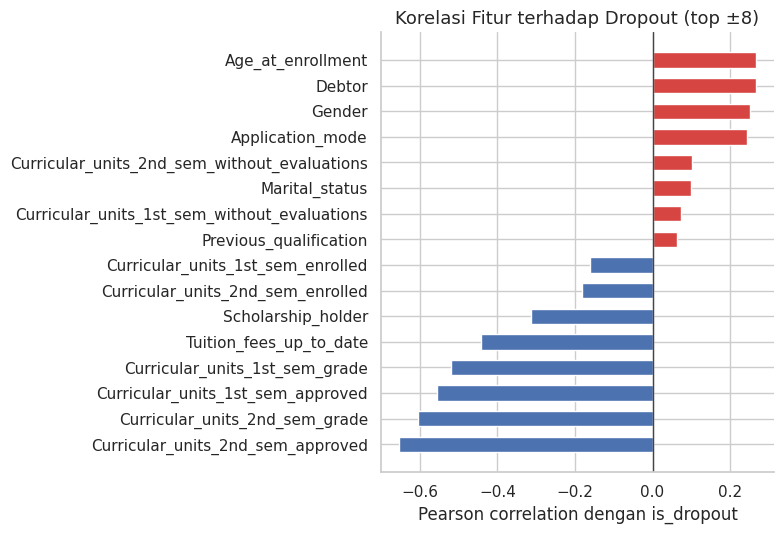

In [9]:
bin_df = df[df["Status"].isin(["Dropout", "Graduate"])].copy()
bin_df["is_dropout"] = (bin_df["Status"] == "Dropout").astype(int)
corr = (bin_df.drop(columns=["Status"]).corr(numeric_only=True)["is_dropout"]
        .drop("is_dropout").sort_values())
top = pd.concat([corr.head(8), corr.tail(8)])
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(top.index, top.values,
        color=["#4C72B0" if v < 0 else "#D64541" for v in top.values], height=0.6)
ax.axvline(0, color="#444", lw=1)
ax.set_title("Korelasi Fitur terhadap Dropout (top ±8)", fontsize=13)
ax.set_xlabel("Pearson correlation dengan is_dropout")
plt.tight_layout()
plt.show()

**Insight:** korelasi negatif terkuat adalah jumlah unit yang lulus & nilai semester 1–2 serta `Tuition_fees_up_to_date` dan `Scholarship_holder` (semakin baik → semakin kecil risiko dropout). Korelasi positif terkuat: `Debtor`, `Age_at_enrollment`, dan `Gender` (laki-laki).

## 5. Data Preparation / Preprocessing

Langkah yang dilakukan:
1. **Filter data latih** — hanya siswa berstatus `Dropout` dan `Graduate` (outcome sudah final). Siswa `Enrolled` dikeluarkan dari training karena outcome-nya belum diketahui — justru merekalah yang nantinya di-scoring oleh model.
2. **Target biner** — `1 = Dropout`, `0 = Graduate`.
3. Seluruh 36 fitur sudah numerik (kategori sudah ter-encode dari sumber data) dan tidak ada missing value, sehingga tidak diperlukan imputation/encoding tambahan.
4. **Standardisasi** fitur dengan `StandardScaler` (di dalam pipeline, sehingga aman dari data leakage).
5. **Split** 80% train / 20% test dengan stratifikasi target.

In [10]:
train_df = df[df["Status"].isin(["Dropout", "Graduate"])].copy()
train_df["target"] = (train_df["Status"] == "Dropout").astype(int)
X = train_df.drop(columns=["Status", "target"])
y = train_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Proporsi dropout (train): {y_train.mean():.3f}")

Train: (2904, 36), Test: (726, 36)
Proporsi dropout (train): 0.392


## 6. Modeling

Dua algoritma dibandingkan dengan 5-fold cross-validation (metrik F1):
- **Logistic Regression** — baseline linier yang interpretable.
- **Random Forest** — ensemble non-linier, sekaligus sumber feature importance.

In [11]:
candidates = {
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))]),
    "RandomForest": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(
            n_estimators=300, min_samples_leaf=2, class_weight="balanced",
            random_state=RANDOM_STATE, n_jobs=-1))]),
}

rows = {}
for name, pipe in candidates.items():
    cv = cross_val_score(pipe, X_train, y_train, cv=5, scoring="f1")
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    rows[name] = {"CV F1 (mean)": cv.mean(),
                  "Accuracy": accuracy_score(y_test, pred),
                  "Precision": precision_score(y_test, pred),
                  "Recall": recall_score(y_test, pred),
                  "F1": f1_score(y_test, pred),
                  "ROC-AUC": roc_auc_score(y_test, proba)}
pd.DataFrame(rows).T.round(4)

,CV F1 (mean),Accuracy,Precision,Recall,F1,ROC-AUC
LogisticRegression,0.8740,0.9421,0.9321,0.9190,0.9255,0.9733
RandomForest,0.8676,0.9229,0.9161,0.8838,0.8996,0.9709


## 7. Evaluation

**Logistic Regression** terpilih sebagai model final (F1 dan ROC-AUC tertinggi, sekaligus paling sederhana dan interpretable).

/usr/local/lib/python3.11/dist-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


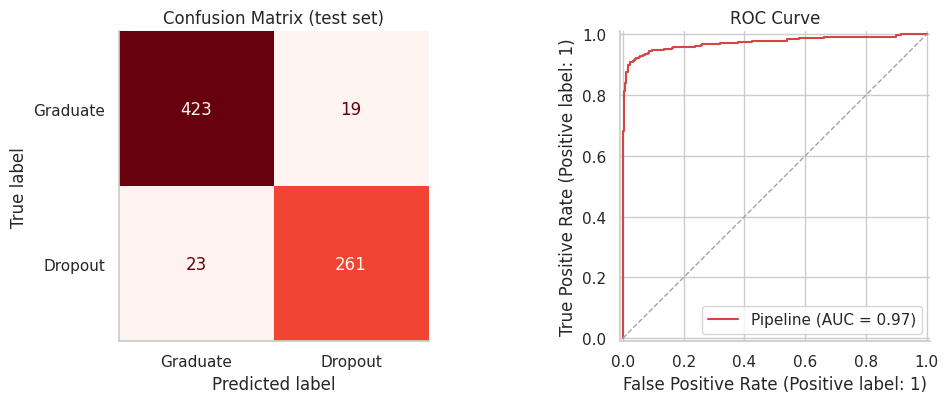

              precision    recall  f1-score   support

    Graduate       0.95      0.96      0.95       442
     Dropout       0.93      0.92      0.93       284

    accuracy                           0.94       726
   macro avg       0.94      0.94      0.94       726
weighted avg       0.94      0.94      0.94       726



In [12]:
best_model = candidates["LogisticRegression"]
pred = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred, display_labels=["Graduate", "Dropout"],
    cmap="Reds", colorbar=False, ax=axes[0])
axes[0].set_title("Confusion Matrix (test set)")
axes[0].grid(False)
RocCurveDisplay.from_estimator(best_model, X_test, y_test,
                               ax=axes[1], color="#D64541")
axes[1].plot([0, 1], [0, 1], ls="--", color="#9AA5B1", lw=1)
axes[1].set_title("ROC Curve")
plt.tight_layout()
plt.show()

print(classification_report(y_test, pred, target_names=["Graduate", "Dropout"]))

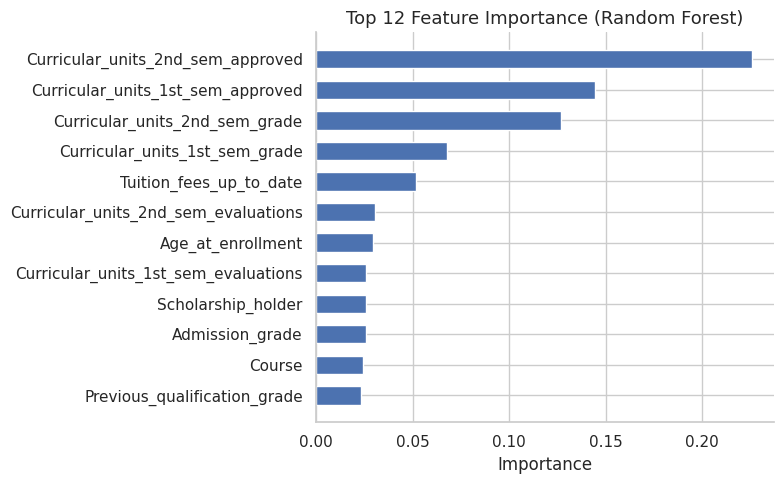

In [13]:
rf = candidates["RandomForest"].named_steps["clf"]
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values().tail(12)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp.index, imp.values, color="#4C72B0", height=0.6)
ax.set_title("Top 12 Feature Importance (Random Forest)", fontsize=13)
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

**Hasil model final (Logistic Regression, test set):** Accuracy **94,2%**, Precision **93,2%**, Recall **91,9%**, F1 **92,6%**, ROC-AUC **0,973**. Recall 91,9% berarti model berhasil menangkap ±92 dari setiap 100 siswa yang benar-benar dropout — sesuai kebutuhan bisnis untuk deteksi dini.

### Menyimpan model

In [14]:
import os
os.makedirs("model", exist_ok=True)
joblib.dump(best_model, "model/model.joblib")
print("Model tersimpan di model/model.joblib")

# Skor risiko untuk seluruh siswa (dipakai di dashboard Metabase)
risk = best_model.predict_proba(df.drop(columns=["Status"]))[:, 1]
print(pd.DataFrame({"Status": df["Status"], "risk": risk})
        .groupby("Status")["risk"].mean().round(3))

Model tersimpan di model/model.joblib
Status
Dropout     0.831
Enrolled    0.485
Graduate    0.120
Name: risk, dtype: float64


Skor risiko rata-rata per kelompok: Dropout 0,83 — Enrolled 0,49 — Graduate 0,12. Model memberi skor tinggi pada siswa yang benar-benar dropout dan skor menengah pada siswa `Enrolled`, sehingga skor ini dapat dipakai untuk **memprioritaskan bimbingan** bagi siswa aktif.

## 8. Conclusion

1. **Tingkat dropout Jaya Jaya Institut mencapai 32,1%** (1.421 dari 4.424 siswa) — hampir 1 dari 3 siswa.
2. **Faktor terkuat dropout** adalah performa akademik semester awal dan faktor finansial. Berdasarkan *feature importance* model, fitur paling berpengaruh berturut-turut: `Curricular_units_2nd_sem_approved` (0,226), `Curricular_units_1st_sem_approved` (0,144), `Curricular_units_2nd_sem_grade` (0,127), `Curricular_units_1st_sem_grade` (0,068), `Tuition_fees_up_to_date` (0,052), `Age_at_enrollment` (0,030), dan `Scholarship_holder` (0,026). Faktor demografi (laki-laki, usia mendaftar ≥25 tahun) serta program studi tertentu (Biofuel Production Tech 67%, Equinculture 55%, Informatics Engineering 54%) juga meningkatkan risiko.
3. **Model Logistic Regression** mampu memprediksi dropout dengan accuracy 94,2%, recall 91,9%, dan ROC-AUC 0,973 — siap dipakai untuk deteksi dini.
4. Model dan dashboard memungkinkan institusi beralih dari reaktif menjadi **proaktif**: siswa berisiko teridentifikasi sejak semester 1–2, sebelum benar-benar berhenti.

## 9. Rekomendasi Action Items

1. **Early-warning system** — jalankan skor risiko model setiap akhir semester untuk seluruh siswa aktif; siswa dengan skor > 0,6 otomatis masuk daftar bimbingan khusus.
2. **Intervensi finansial** — hubungi siswa yang menunggak biaya kuliah sebelum tunggakan menumpuk (dropout rate kelompok ini 86,6%); perluas program beasiswa/cicilan, karena penerima beasiswa dropout 3× lebih jarang.
3. **Program remedial semester awal** — siswa yang lulus < 3 unit di semester 1 wajib mendapat academic advising dan kelas remedial, karena unit approved semester 1–2 adalah prediktor terkuat.
4. **Audit program studi berisiko tinggi** — evaluasi kurikulum dan beban studi pada program dengan dropout > 45% (Biofuel Production Tech, Equinculture, Informatics Engineering, Management malam).
5. **Dukungan siswa dewasa & kelas malam** — sediakan jadwal fleksibel/kelas hybrid untuk siswa usia 25+ dan kelas malam yang dropout rate-nya jauh di atas rata-rata.
6. **Monitoring rutin lewat dashboard Metabase** — pantau KPI dropout rate per program studi, status pembayaran, dan distribusi skor risiko setiap bulan.
